# Visualisierung der Analyseergebnisse

In diesem Notebook werden die Ergebnisse der NLP-Analyse grafisch dargestellt. Ziel ist es, die häufigsten Begriffe und identifizierten Themen visuell verständlich aufzubereiten.

## Import der benötigten Bibliotheken

Für die Visualisierung werden matplotlib und WordCloud verwendet.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud

## Laden der vorverarbeiteten Texte

Die bereinigten und lemmatisierten Texte werden geladen und für die Visualisierung verwendet.

In [8]:
df = pd.read_csv("../processed_data/02_preprocessed_data.csv")

In [9]:
text = " ".join(df['processed_text'].astype(str))

## Erstellung einer Wordcloud

Die Wordcloud visualisiert die am häufigsten vorkommenden Begriffe innerhalb der Beschwerdetexte. Häufig verwendete Wörter werden dabei größer dargestellt.

In [10]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

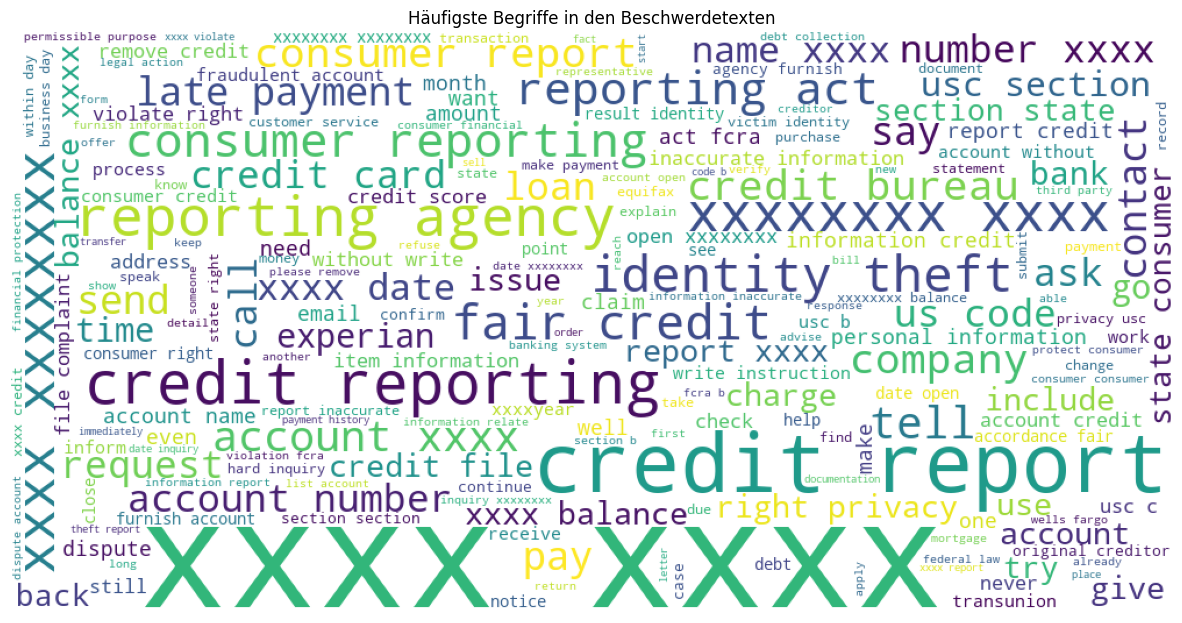

In [11]:
plt.figure(figsize=(15, 8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Häufigste Begriffe in den Beschwerdetexten")

plt.show()

## Berechnung der häufigsten Begriffe

Für die Visualisierung werden die häufigsten Begriffe des Bag-of-Words-Modells erneut berechnet.

In [12]:
import pickle

In [13]:
with open("../processed_data/03_bow_vectors.pkl", "rb") as f:
    X_bow = pickle.load(f)

with open("../processed_data/03_bow_vectorizer.pkl", "rb") as f:
    bow_vectorizer = pickle.load(f)

In [14]:
import numpy as np

In [15]:
bow_sum = X_bow.sum(axis=0)

bow_freq = [
    (word, bow_sum[0, idx])
    for word, idx in bow_vectorizer.vocabulary_.items()
]

bow_freq = sorted(
    bow_freq,
    key=lambda x: x[1],
    reverse=True
)

## Visualisierung der häufigsten Begriffe

Die häufigsten Begriffe des Datensatzes werden als Balkendiagramm dargestellt.

In [16]:
top_words = bow_freq[:10]

words = [word[0] for word in top_words]

counts = [word[1] for word in top_words]

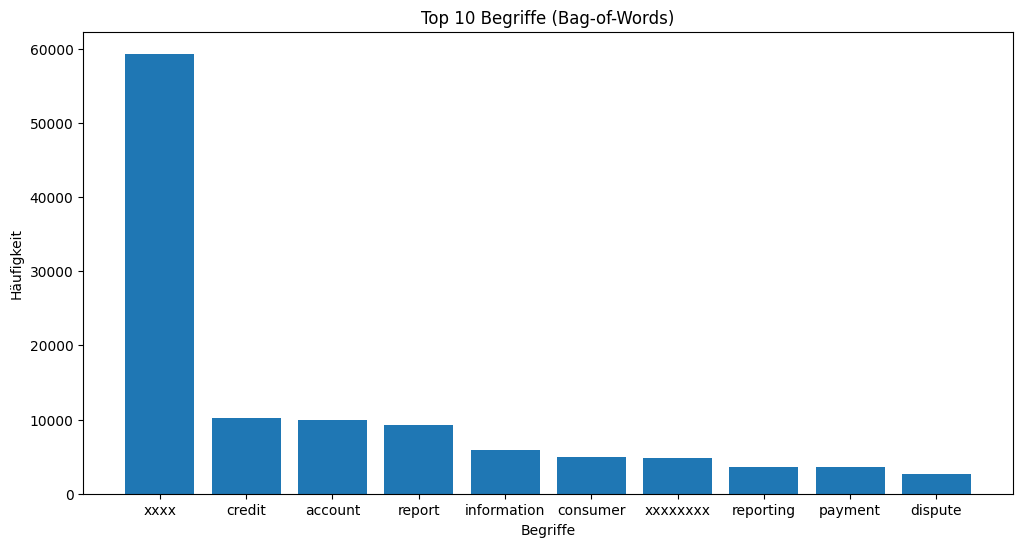

In [17]:
plt.figure(figsize=(12, 6))

plt.bar(words, counts)

plt.title("Top 10 Begriffe (Bag-of-Words)")

plt.xlabel("Begriffe")

plt.ylabel("Häufigkeit")

plt.show()

## Zusammenfassung der identifizierten Themen

Die Visualisierungen bestätigen die Ergebnisse der semantischen Analyse. Besonders häufig treten Begriffe rund um Kreditberichte, Konten, Zahlungen, Streitfälle und Inkassoverfahren auf.

In [18]:
topics = {
    "Credit Reports": 1,
    "Loans & Payments": 2,
    "Consumer Rights": 3,
    "Late Payments": 4,
    "Debt Collection": 5
}

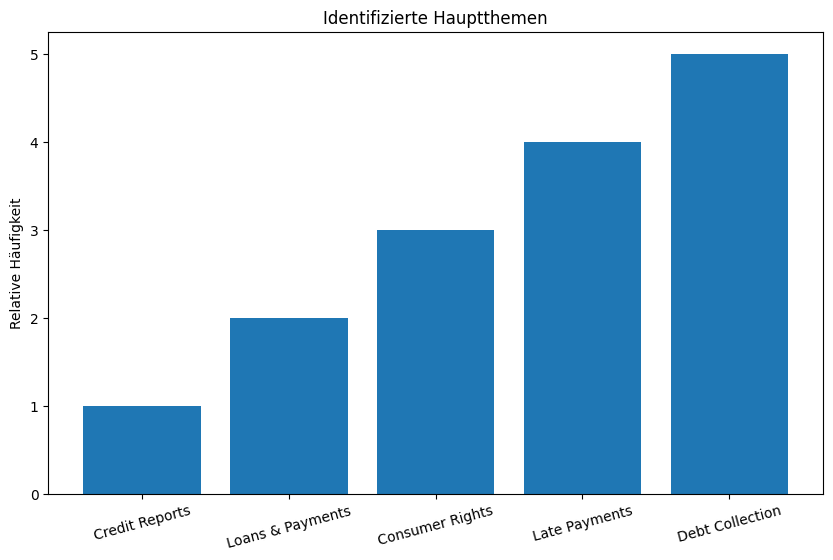

In [19]:
plt.figure(figsize=(10, 6))

plt.bar(topics.keys(), topics.values())

plt.title("Identifizierte Hauptthemen")

plt.ylabel("Relative Häufigkeit")

plt.xticks(rotation=15)

plt.show()

## Interpretation der Visualisierung

Die Visualisierungen verdeutlichen die zentralen Beschwerdeschwerpunkte des Datensatzes. Besonders häufig treten Probleme im Zusammenhang mit Kreditberichten, Konten, Zahlungsverhalten und Inkassoverfahren auf.

Die Kombination aus Textvorverarbeitung, Vektorisierung, semantischer Analyse und Visualisierung ermöglicht eine effiziente Analyse großer Mengen unstrukturierter Beschwerdetexte und unterstützt die Identifikation relevanter Themenbereiche.